# Часть 1 Бустинг (5 баллов)

В этой части будем предсказывать зарплату data scientist-ов в зависимости  от ряда факторов с помощью градиентного бустинга.

В датасете есть следующие признаки:



* work_year: The number of years of work experience in the field of data science.

* experience_level: The level of experience, such as Junior, Senior, or Lead.

* employment_type: The type of employment, such as Full-time or Contract.

* job_title: The specific job title or role, such as Data Analyst or Data Scientist.

* salary: The salary amount for the given job.

* salary_currency: The currency in which the salary is denoted.

* salary_in_usd: The equivalent salary amount converted to US dollars (USD) for comparison purposes.

* employee_residence: The country or region where the employee resides.

* remote_ratio: The percentage of remote work offered in the job.

* company_location: The location of the company or organization.

* company_size: The company's size is categorized as Small, Medium, or Large.

In [1]:
import os
os.environ["OMP_NUM_THREADS"] = "4"

In [3]:
import pandas as pd

df = pd.read_csv("ds_salaries.csv")
df.head()

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2023,SE,FT,Principal Data Scientist,80000,EUR,85847,ES,100,ES,L
1,2023,MI,CT,ML Engineer,30000,USD,30000,US,100,US,S
2,2023,MI,CT,ML Engineer,25500,USD,25500,US,100,US,S
3,2023,SE,FT,Data Scientist,175000,USD,175000,CA,100,CA,M
4,2023,SE,FT,Data Scientist,120000,USD,120000,CA,100,CA,M


In [5]:
import numpy as np

## Задание 1 (0.5 балла) Подготовка



*   Разделите выборку на train, val, test (80%, 10%, 10%)
*   Выдерите salary_in_usd в качестве таргета
*   Найдите и удалите признак, из-за которого возможен лик в данных


In [5]:
from sklearn.model_selection import train_test_split

df = pd.read_csv("ds_salaries.csv")

target = df['salary_in_usd']

df = df.drop(['salary', 'salary_currency', 'salary_in_usd'], axis=1)

X_temp, X_test, y_temp, y_test = train_test_split(
    df, target, 
    test_size=0.1, 
    random_state=1504
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.111,
    random_state=1504
)


print(f"Train size: {len(X_train)} ({len(X_train)/len(df):.1%})")
print(f"Val size: {len(X_val)} ({len(X_val)/len(df):.1%})")
print(f"Test size: {len(X_test)} ({len(X_test)/len(df):.1%})")

Train size: 3003 (80.0%)
Val size: 376 (10.0%)
Test size: 376 (10.0%)


## Задание 2 (0.5 балла) Линейная модель


*   Закодируйте категориальные  признаки с помощью OneHotEncoder
*   Обучите модель линейной регрессии
*   Оцените  качество через MAPE и RMSE


In [7]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

categorical_features = [
    'experience_level', 
    'employment_type', 
    'job_title',
    'employee_residence', 
    'company_location', 
    'company_size'
]

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ],
    remainder='passthrough'
)

model = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mape = mean_absolute_percentage_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print('MAPE:', mape)
print('RMSE:', rmse)

MAPE: 0.36320103383461844
RMSE: 45908.629318410836


## Задание 3 (0.5 балла) XGboost

Начнем с библиотеки xgboost.

Обучите модель `XGBRegressor` на тех же данных, что линейную модель, подобрав оптимальные гиперпараметры (`max_depth, learning_rate, n_estimators, gamma`, etc.) по валидационной выборке. Оцените качество итоговой модели (MAPE, RMSE), скорость обучения и скорость предсказания.

In [17]:
import time
import xgboost as xgb

print("Преобразование данных...")
X_train_final = preprocessor.fit_transform(X_train)
X_val_final = preprocessor.transform(X_val)
X_test_final = preprocessor.transform(X_test)

dtrain = xgb.DMatrix(X_train_final, label=y_train)
dval = xgb.DMatrix(X_val_final, label=y_val)
dtest = xgb.DMatrix(X_test_final)

base_params = {
    'objective': 'reg:squarederror',
    'eval_metric': 'rmse',
    'seed': 1504
}

def optimize_xgb_params(dtrain, dval):
    best_rmse = float('inf')
    best_params = {}
    best_iterations = 0
    
    param_grid = {
        'max_depth': [5, 7, 9],
        'learning_rate': [0.05, 0.1, 0.2, 0.5],
        'gamma': [0, 0.1, 0.2],
        'subsample': [0.5, 0.8, 1.0],
        'colsample_bytree': [0.5, 0.8, 1.0]
    }
    
    print("Начало подбора гиперпараметров...")
    start_time = time.time()
    
    for max_depth in param_grid['max_depth']:
        for lr in param_grid['learning_rate']:
            for gamma in param_grid['gamma']:
                for subsample in param_grid['subsample']:
                    for colsample in param_grid['colsample_bytree']:
                        params = {
                            **base_params,
                            'max_depth': max_depth,
                            'learning_rate': lr,
                            'gamma': gamma,
                            'subsample': subsample,
                            'colsample_bytree': colsample
                        }

                        model = xgb.train(
                            params,
                            dtrain,
                            num_boost_round=1000,
                            evals=[(dval, 'eval')],
                            early_stopping_rounds=50,
                            verbose_eval=False
                        )

                        best_iter = model.best_iteration
                        best_rmse_val = model.best_score

                        if best_rmse_val < best_rmse:
                            best_rmse = best_rmse_val
                            best_params = params
                            best_iterations = best_iter
                            print(f"Новые параметры: depth={max_depth}, lr={lr:.2f}, "
                                  f"gamma={gamma}, sub={subsample}, col={colsample} | "
                                  f"RMSE={best_rmse:.2f}, Итерации={best_iter}")
    
    tuning_time = time.time() - start_time
    print(f"Подбор завершен за {tuning_time:.1f} сек")
    return {'params': best_params, 'iterations': best_iterations, 'rmse': best_rmse}

optimal = optimize_xgb_params(dtrain, dval)

print("\nЛучшие параметры:")
for key, value in optimal['params'].items():
    print(f"{key}: {value}")
print(f"Лучшее количество итераций: {optimal['iterations']}")
print(f"Лучший RMSE на валидации: {optimal['rmse']:.2f}")

print("\nПодготовка финальных данных...")
X_temp_final = preprocessor.transform(X_temp)
dtrain_final = xgb.DMatrix(X_temp_final, label=y_temp)

print("Обучение финальной модели...")
start_train = time.time()
final_model = xgb.train(
    optimal['params'],
    dtrain_final,
    num_boost_round=optimal['iterations']
)
train_time = time.time() - start_train

start_pred = time.time()
y_test_pred = final_model.predict(dtest)
pred_time = time.time() - start_pred

test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
test_mape = mean_absolute_percentage_error(y_test, y_test_pred)

print("\nФинальные результаты на тестовой выборке:")
print(f"Test RMSE: {test_rmse:.2f}")
print(f"Test MAPE: {test_mape:.4f}")
print(f"Время обучения: {train_time:.2f} сек")
print(f"Время предсказания: {pred_time:.4f} сек")

Преобразование данных...
Начало подбора гиперпараметров...
Новые параметры: depth=5, lr=0.05, gamma=0, sub=0.5, col=0.5 | RMSE=46082.55, Итерации=139
Новые параметры: depth=5, lr=0.10, gamma=0, sub=0.8, col=0.5 | RMSE=46026.45, Итерации=70
Новые параметры: depth=5, lr=0.20, gamma=0, sub=0.8, col=0.5 | RMSE=45906.51, Итерации=59
Новые параметры: depth=7, lr=0.10, gamma=0, sub=0.8, col=0.5 | RMSE=45869.73, Итерации=59
Новые параметры: depth=9, lr=0.50, gamma=0, sub=1.0, col=0.5 | RMSE=45757.41, Итерации=7
Подбор завершен за 270.0 сек

Лучшие параметры:
objective: reg:squarederror
eval_metric: rmse
seed: 1504
max_depth: 9
learning_rate: 0.5
gamma: 0
subsample: 1.0
colsample_bytree: 0.5
Лучшее количество итераций: 7
Лучший RMSE на валидации: 45757.41

Подготовка финальных данных...
Обучение финальной модели...

Финальные результаты на тестовой выборке:
Test RMSE: 44566.02
Test MAPE: 0.3425
Время обучения: 0.07 сек
Время предсказания: 0.0020 сек


## Задание 4 (1 балл) CatBoost

Теперь библиотека CatBoost.

Обучите модель `CatBoostRegressor`, подобрав оптимальные гиперпараметры (`depth, learning_rate, iterations`, etc.) по валидационной выборке. Оцените качество итоговой модели (MAPE, RMSE), скорость обучения и скорость предсказания.

In [25]:
from catboost import CatBoostRegressor

cat_feature_indices = [i for i, col in enumerate(X_train.columns) 
                       if col in categorical_features]

best_mape = float('inf')
best_params = {}
best_iterations = 0
start_tuning = time.time()

param_grid = {
    'depth': [6, 8],
    'learning_rate': [0.05, 0.1],
    'l2_leaf_reg': [3, 5]
}

print("Начало подбора гиперпараметров для CatBoost...")
for depth in param_grid['depth']:
    for lr in param_grid['learning_rate']:
        for l2 in param_grid['l2_leaf_reg']:
            model = CatBoostRegressor(
                depth=depth,
                learning_rate=lr,
                iterations=1000,
                l2_leaf_reg=l2,
                cat_features=cat_feature_indices,
                random_seed=1504,
                early_stopping_rounds=50,
                verbose=0,
                thread_count=-1
            )
            
            model.fit(
                X_train, y_train,
                eval_set=(X_val, y_val)
            )
            
            best_iter = model.best_iteration_
            y_val_pred = model.predict(X_val)
            
            mape = mean_absolute_percentage_error(y_val, y_val_pred)
            rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
            
            if mape < best_mape:
                best_mape = mape
                best_iterations = best_iter
                best_params = {
                    'depth': depth,
                    'learning_rate': lr,
                    'l2_leaf_reg': l2
                }
                print(f"Новые лучшие параметры: depth={depth}, lr={lr:.3f}, l2={l2} | "
                      f"MAPE: {mape:.4f}, Итерации: {best_iter}")

tuning_time = time.time() - start_tuning
print(f"\nПодбор завершен за {tuning_time:.1f} сек")
print(f"Лучшие параметры: {best_params}")
print(f"Лучшее количество итераций: {best_iterations}")
print(f"Лучший MAPE на валидации: {best_mape:.4f}")

print("\nОбучение финальной модели CatBoost...")
final_model = CatBoostRegressor(
    **best_params,
    iterations=best_iterations,
    cat_features=cat_feature_indices,
    random_seed=1504,
    verbose=0,
    thread_count=-1
)

start_train = time.time()
final_model.fit(X_temp, y_temp)
train_time = time.time() - start_train

start_pred = time.time()
y_test_pred = final_model.predict(X_test)
pred_time = time.time() - start_pred

test_mape = mean_absolute_percentage_error(y_test, y_test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

print("\nФинальные результаты для CatBoost:")
print(f"Test MAPE: {test_mape:.4f}")
print(f"Test RMSE: {test_rmse:.2f}")
print(f"Время обучения: {train_time:.2f} сек")
print(f"Время предсказания: {pred_time:.4f} сек")

feature_importance = final_model.get_feature_importance()
feature_names = X_train.columns
sorted_indices = np.argsort(feature_importance)[::-1][:10]

Начало подбора гиперпараметров для CatBoost...
Новые лучшие параметры: depth=6, lr=0.050, l2=3 | MAPE: 0.3586, Итерации: 162

Подбор завершен за 171.4 сек
Лучшие параметры: {'depth': 6, 'learning_rate': 0.05, 'l2_leaf_reg': 3}
Лучшее количество итераций: 162
Лучший MAPE на валидации: 0.3586

Обучение финальной модели CatBoost...

Финальные результаты для CatBoost:
Test MAPE: 0.3426
Test RMSE: 44529.05
Время обучения: 14.87 сек
Время предсказания: 0.0080 сек

Топ-10 важных признаков:
employee_residence: 32.5227
experience_level: 27.6361
job_title: 19.9403
company_location: 7.4214
company_size: 6.0463
work_year: 3.2910
remote_ratio: 2.4156
employment_type: 0.7266


Для применения catboost моделей не обязательно сначала кодировать категориальные признаки, модель может кодировать их сама. Обучите catboost с подбором оптимальных гиперпараметров снова, используя pool для передачи данных в модель с указанием какие признаки категориальные, а какие нет с помощью параметра cat_features. Оцените качество и время. Стало ли лучше?

In [27]:
from catboost import Pool

cat_feature_indices = [i for i, col in enumerate(X_train.columns) 
                       if col in categorical_features]

train_pool = Pool(X_train, y_train, cat_features=cat_feature_indices)
val_pool = Pool(X_val, y_val, cat_features=cat_feature_indices)
temp_pool = Pool(X_temp, y_temp, cat_features=cat_feature_indices)
test_pool = Pool(X_test, cat_features=cat_feature_indices)

best_mape = float('inf')
best_params = {}
best_iterations = 0
start_tuning = time.time()

param_grid = {
    'depth': [6, 8],
    'learning_rate': [0.05, 0.1],
    'l2_leaf_reg': [3, 5]
}

print("Начало подбора гиперпараметров для CatBoost с использованием Pool...")
for depth in param_grid['depth']:
    for lr in param_grid['learning_rate']:
        for l2 in param_grid['l2_leaf_reg']:
            model = CatBoostRegressor(
                depth=depth,
                learning_rate=lr,
                iterations=1000,
                l2_leaf_reg=l2,
                random_seed=1504,
                early_stopping_rounds=50,
                verbose=0,
                thread_count=-1
            )
            
            start_fit = time.time()
            model.fit(
                train_pool,
                eval_set=val_pool,
                use_best_model=True
            )
            fit_time = time.time() - start_fit
            
            best_iter = model.best_iteration_
            
            start_pred = time.time()
            y_val_pred = model.predict(val_pool)
            pred_time = time.time() - start_pred
            
            mape = mean_absolute_percentage_error(y_val, y_val_pred)
            rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
            
            if mape < best_mape:
                best_mape = mape
                best_iterations = best_iter
                best_params = {
                    'depth': depth,
                    'learning_rate': lr,
                    'l2_leaf_reg': l2
                }
                print(f"Новые лучшие параметры: depth={depth}, lr={lr:.3f}, l2={l2} | "
                      f"MAPE: {mape:.4f}, Итерации: {best_iter} | "
                      f"Время обучения: {fit_time:.1f}с, предсказания: {pred_time:.4f}с")

tuning_time = time.time() - start_tuning
print(f"\nПодбор завершен за {tuning_time:.1f} сек")
print(f"Лучшие параметры: {best_params}")
print(f"Лучшее количество итераций: {best_iterations}")
print(f"Лучший MAPE на валидации: {best_mape:.4f}")

print("\nОбучение финальной модели CatBoost с использованием Pool...")
final_model = CatBoostRegressor(
    **best_params,
    iterations=best_iterations,
    random_seed=1504,
    verbose=0,
    thread_count=-1
)

start_train = time.time()
final_model.fit(temp_pool)
train_time = time.time() - start_train

start_pred = time.time()
y_test_pred = final_model.predict(test_pool)
pred_time = time.time() - start_pred

test_mape = mean_absolute_percentage_error(y_test, y_test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

print("\nФинальные результаты для CatBoost с Pool:")
print(f"Test MAPE: {test_mape:.4f}")
print(f"Test RMSE: {test_rmse:.2f}")
print(f"Время обучения: {train_time:.2f} сек")
print(f"Время предсказания: {pred_time:.4f} сек")

feature_importance = final_model.get_feature_importance()
feature_names = X_train.columns
sorted_indices = np.argsort(feature_importance)[::-1][:10]

print("\nТоп-10 важных признаков:")
for i in sorted_indices:
    print(f"{feature_names[i]}: {feature_importance[i]:.4f}")

Начало подбора гиперпараметров для CatBoost с использованием Pool...
Новые лучшие параметры: depth=6, lr=0.050, l2=3 | MAPE: 0.3586, Итерации: 162 | Время обучения: 19.4с, предсказания: 0.0030с

Подбор завершен за 162.3 сек
Лучшие параметры: {'depth': 6, 'learning_rate': 0.05, 'l2_leaf_reg': 3}
Лучшее количество итераций: 162
Лучший MAPE на валидации: 0.3586

Обучение финальной модели CatBoost с использованием Pool...

Финальные результаты для CatBoost с Pool:
Test MAPE: 0.3426
Test RMSE: 44529.05
Время обучения: 14.74 сек
Время предсказания: 0.0029 сек

Топ-10 важных признаков:
employee_residence: 32.5227
experience_level: 27.6361
job_title: 19.9403
company_location: 7.4214
company_size: 6.0463
work_year: 3.2910
remote_ratio: 2.4156
employment_type: 0.7266


**Ответ:** Хотя общее качество модели не изменилось, ускорение предсказания в 2.75 раза - это значимое улучшение для production-систем, где важна скорость инференса.

## Задание 5 (0.5 балла) LightGBM

И наконец библиотека LightGBM - используйте `LGBMRegressor`, снова подберите гиперпараметры, оцените качество и скорость.


In [13]:
from lightgbm import LGBMRegressor, early_stopping, log_evaluation

for df in [X_train, X_val, X_temp, X_test]:
    for col in categorical_features:
        df[col] = df[col].astype('category')

best_mape = float('inf')
best_params = {}
best_iterations = 0
param_grid = {
    'max_depth': [5, 7],
    'learning_rate': [0.05, 0.1],
    'n_estimators': [100, 200],
    'num_leaves': [31, 63],
    'min_child_samples': [20, 50]
}

print("Начало подбора гиперпараметров для LightGBM...")
start_tuning = time.time()

for max_depth in param_grid['max_depth']:
    for lr in param_grid['learning_rate']:
        for n_est in param_grid['n_estimators']:
            for num_leaves in param_grid['num_leaves']:
                for min_child in param_grid['min_child_samples']:
                    model = LGBMRegressor(
                        max_depth=max_depth,
                        learning_rate=lr,
                        n_estimators=n_est,
                        num_leaves=num_leaves,
                        min_child_samples=min_child,
                        random_state=1504,
                        n_jobs=-1,
                        verbose=-1
                    )

                    start_train = time.time()
                    model.fit(
                        X_train, y_train,
                        eval_set=[(X_val, y_val)],
                        eval_metric='mape',
                        callbacks=[
                            early_stopping(stopping_rounds=50),
                            log_evaluation(period=0)
                        ]
                    )
                    train_duration = time.time() - start_train

                    best_iter = model.best_iteration_
                    start_pred = time.time()
                    y_val_pred = model.predict(X_val)
                    pred_duration = time.time() - start_pred

                    mape = mean_absolute_percentage_error(y_val, y_val_pred)

                    if mape < best_mape:
                        best_mape = mape
                        best_iterations = best_iter
                        best_params = {
                            'max_depth': max_depth,
                            'learning_rate': lr,
                            'num_leaves': num_leaves,
                            'min_child_samples': min_child
                        }
                        print(f"Новые лучшие параметры: max_depth={max_depth}, "
                              f"lr={lr:.3f}, num_leaves={num_leaves}, min_child_samples={min_child} "
                              f"| MAPE: {mape:.4f}, Итерации: {best_iter} "
                              f"| Время обучения: {train_duration:.1f}с, предсказания: {pred_duration:.4f}с")

tuning_time = time.time() - start_tuning
print(f"\nПодбор завершен за {tuning_time:.1f} сек")
print(f"Лучшие параметры: {best_params}")
print(f"Лучшее количество итераций: {best_iterations}")
print(f"Лучший MAPE на валидации: {best_mape:.4f}")

print("\nОбучение финальной модели LightGBM...")

final_model = LGBMRegressor(
    **best_params,
    n_estimators=best_iterations,
    random_state=1504,
    n_jobs=-1,
    verbose=-1
)

start_train = time.time()
final_model.fit(X_temp, y_temp)
train_time = time.time() - start_train

start_pred = time.time()
y_test_pred = final_model.predict(X_test)
pred_time = time.time() - start_pred

test_mape = mean_absolute_percentage_error(y_test, y_test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

print("\nФинальные результаты для LightGBM:")
print(f"Test MAPE: {test_mape:.4f}")
print(f"Test RMSE: {test_rmse:.2f}")
print(f"Время обучения: {train_time:.2f} сек")
print(f"Время предсказания: {pred_time:.4f} сек")

if hasattr(final_model, "feature_importances_"):
    feature_importances = final_model.feature_importances_
    feature_names = X_train.columns
    top_features = sorted(zip(feature_names, feature_importances), key=lambda x: -x[1])[:10]

    print("\nТоп-10 важных признаков:")
    for name, score in top_features:
        print(f"{name}: {score:.4f}")


Начало подбора гиперпараметров для LightGBM...
Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[100]	valid_0's mape: 0.35132	valid_0's l2: 2.1919e+09
Новые лучшие параметры: max_depth=5, lr=0.050, num_leaves=31, min_child_samples=20 | MAPE: 0.3513, Итерации: 100 | Время обучения: 1.4с, предсказания: 0.0170с
Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[100]	valid_0's mape: 0.35808	valid_0's l2: 2.21015e+09
Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[100]	valid_0's mape: 0.35132	valid_0's l2: 2.1919e+09
Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[100]	valid_0's mape: 0.35808	valid_0's l2: 2.21015e+09
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[81]	valid_0's mape: 0.354352	valid_0's 

## Задание 6 (2 балла) Сравнение и выводы

Сравните модели бустинга и сделайте про них выводы, какая из моделей показала лучший/худший результат по качеству, скорости обучения и скорости предсказания? Как отличаются гиперпараметры для разных моделей?

**Сравнение моделей бустинга и выводы**
. По качеству предсказания (учитывая одновременно RMSE и MAPE) лучшие результаты показали XGBoost и CatBoost, между которыми практически нет разницы: XGBoost чуть превосходит всех по MAPE (0.3425 vs 0.3426 у CatBoost), а CatBoost оказывается минимально лучше по RMSE (44 529 vs 44 566 у XGBoost). LightGBM заметно отстает, продемонстрировав и более высокий RMSE (45 564), и более высокий MAPE (0.3461).

По скорости подбора гиперпараметров лидер — LightGBM: 57 с против 162–171 с у CatBoost и 270 с у XGBoost. Если же говорить о финальном обучении на всех данных, самым быстрым оказался XGBoost (0.07 с), затем LightGBM (1.32 с) и, существенно позади, CatBoost (~14.8 с). Инференс (предсказание) также быстрее всего выполняется в XGBoost (0.0020 с), чуть дальше — CatBoost с Pool (0.0029 с), за ними «обычный» CatBoost (0.0080 с) и, замыкая, LightGBM (0.0171 с).

Что касается оптимальных гиперпараметров, то XGBoost выбрал очень глубокое дерево (max_depth=9) и высокий learning_rate=0.5, при этом без усечения строк (subsample=1.0) и с половинным отбором столбцов (colsample_bytree=0.5). CatBoost остановился на более консервативных настройках (depth=6, lr=0.05, l2_leaf_reg=3), а LightGBM — на среднем сочетании глубины 7, умеренной скорости обучения (0.1), большом числе листьев (63) и минимуме наблюдений наxost.  


# Часть 2 Кластеризация (5 баллов)

Будем работать с данными о том, каких исполнителей слушают пользователи музыкального сервиса.

Каждая строка таблицы - информация об одном пользователе. Каждый столбец - это исполнитель (The Beatles, Radiohead, etc.)

Для каждой пары (пользователь, исполнитель) в таблице стоит число - доля прослушивания этого исполнителя этим пользователем.


In [1]:
import pandas as pd
ratings = pd.read_excel("https://github.com/evgpat/edu_stepik_rec_sys/blob/main/datasets/sample_matrix.xlsx?raw=true", engine='openpyxl')
ratings.head()

,user,the beatles,radiohead,deathcab for cutie,coldplay,modest mouse,sufjan stevens,dylan. bob,red hot clili peppers,pink fluid,...,municipal waste,townes van zandt,curtis mayfield,jewel,lamb,michal w. smith,群星,agalloch,meshuggah,yellowcard
0,0,NaN,0.020417,NaN,NaN,NaN,NaN,NaN,0.030496,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,NaN,0.184962,0.024561,NaN,NaN,0.136341,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,NaN,NaN,0.028635,NaN,NaN,NaN,0.024559,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,0.043529,0.086281,0.034590,0.016712,0.015935,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Будем строить кластеризацию исполнителей: если двух исполнителей слушало много людей примерно одинаковую долю своего времени (то есть векторы близки в пространстве), то, возможно исполнители похожи. Эта информация может быть полезна при построении рекомендательных систем.

## Задание 1 (0.5 балла) Подготовка

Транспонируем матрицу ratings, чтобы по строкам стояли исполнители.

In [3]:
artist_ratings = ratings.T

In [5]:
artist_ratings.head()

,0,1,2,3,4,5,6,7,8,9,...,4990,4991,4992,4993,4994,4995,4996,4997,4998,4999
user,0.000000,1.000000,2.000000,3.0,4.000000,5.000000,6.0,7.0,8.000000,9.000000,...,4990.000000,4991.0,4992.000000,4993.000000,4994.000000,4995.000000,4996.0,4997.000000,4998.0,4999.000000
the beatles,NaN,NaN,NaN,NaN,0.043529,NaN,NaN,NaN,0.093398,0.017621,...,NaN,NaN,0.121169,0.038168,0.007939,0.017884,NaN,0.076923,NaN,NaN
radiohead,0.020417,0.184962,NaN,NaN,0.086281,0.006322,NaN,NaN,NaN,0.019156,...,0.017735,NaN,NaN,NaN,0.011187,NaN,NaN,NaN,NaN,NaN
deathcab for cutie,NaN,0.024561,0.028635,NaN,0.034590,NaN,NaN,NaN,NaN,0.013349,...,0.121344,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.027893
coldplay,NaN,NaN,NaN,NaN,0.016712,NaN,NaN,NaN,NaN,NaN,...,0.217175,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Выкиньте строку под названием `user`.

In [7]:
artist_ratings = artist_ratings.drop('user', axis=0)

In [9]:
artist_ratings.head()

,0,1,2,3,4,5,6,7,8,9,...,4990,4991,4992,4993,4994,4995,4996,4997,4998,4999
the beatles,NaN,NaN,NaN,NaN,0.043529,NaN,NaN,NaN,0.093398,0.017621,...,NaN,NaN,0.121169,0.038168,0.007939,0.017884,NaN,0.076923,NaN,NaN
radiohead,0.020417,0.184962,NaN,NaN,0.086281,0.006322,NaN,NaN,NaN,0.019156,...,0.017735,NaN,NaN,NaN,0.011187,NaN,NaN,NaN,NaN,NaN
deathcab for cutie,NaN,0.024561,0.028635,NaN,0.034590,NaN,NaN,NaN,NaN,0.013349,...,0.121344,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.027893
coldplay,NaN,NaN,NaN,NaN,0.016712,NaN,NaN,NaN,NaN,NaN,...,0.217175,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
modest mouse,NaN,NaN,NaN,NaN,0.015935,NaN,NaN,NaN,NaN,0.030437,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


В таблице много пропусков, так как пользователи слушают не всех-всех исполнителей, чья музыка представлена в сервисе, а некоторое подмножество (обычно около 30 исполнителей)


Доля исполнителя в музыке, прослушанной  пользователем, равна 0, если пользователь никогда не слушал музыку данного музыканта, поэтому заполните пропуски нулями.



In [11]:
artist_ratings = artist_ratings.fillna(0)
artist_ratings.sample()

,0,1,2,3,4,5,6,7,8,9,...,4990,4991,4992,4993,4994,4995,4996,4997,4998,4999
ryan adams,0.0,0.0,0.015999,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Задание 2 (0.5 балла) Первая кластеризация

Примените KMeans с 5ю кластерами, сохраните полученные лейблы

In [65]:
from collections import Counter
from threadpoolctl import threadpool_limits
from sklearn.cluster import KMeans

with threadpool_limits(limits=4):
    kmeans = KMeans(n_clusters=5, random_state=42)
    cluster_labels = kmeans.fit_predict(artist_ratings)

cluster_sizes = Counter(cluster_labels)
for cluster_id, size in sorted(cluster_sizes.items()):
    print(f"Кластер {cluster_id}: {size} исполнителей")

Кластер 0: 115 исполнителей
Кластер 1: 1 исполнителей
Кластер 2: 1 исполнителей
Кластер 3: 882 исполнителей
Кластер 4: 1 исполнителей


Выведите размеры кластеров. Полезной ли получилась кластеризация? Почему KMeans может выдать такой результат?

In [32]:
from collections import Counter

cluster_sizes = Counter(cluster_labels)
for cluster_id, size in sorted(cluster_sizes.items()):
    print(f"Кластер {cluster_id}: {size} исполнителей")

Кластер 0: 115 исполнителей
Кластер 1: 1 исполнителей
Кластер 2: 1 исполнителей
Кластер 3: 882 исполнителей
Кластер 4: 1 исполнителей


**Ответ:** Получилась крайне неравномерная разбивка: почти все исполнители (882 из ~1 000) оказались в одном «большом» и одном "среднем" кластере, тогда как остальные группы содержат по несколько (или даже по одному) артисту. Такое распределение говорит о том, что в высокоразреженном многомерном пространстве (каждый вектор — почти сплошь нули) KMeans с Евклидовой метрикой просто «склеивает» большинство близких к нулю точек в один кластер, выделяя лишь несколько аномальных или «богато представленных» артистов в отдельные, малые группы. В итоге кластеризация в исходном виде малоинформативна для поиска тематических или жанровых сообществ, и для получения более осмысленных кластеров нужен либо отбор/снижение размерности, либо метрика, устойчивые к разреженности (косинусная близость и др.).

## Задание 3 (0.5 балла) Объяснение результатов

При кластеризации получилось $\geq 1$ кластера размера 1. Выведите исполнителей, которые составляют такие кластеры. Среди них должна быть группа The Beatles.

In [34]:
artist_clusters = pd.DataFrame({
    'artist': artist_ratings.index,
    'cluster': cluster_labels
})

cluster_sizes = artist_clusters['cluster'].value_counts()
singleton_clusters = cluster_sizes[cluster_sizes == 1].index

singleton_artists = artist_clusters[
    artist_clusters['cluster'].isin(singleton_clusters)
]['artist'].tolist()

print("Исполнители, оказавшиеся в кластерах размера 1:")
print(singleton_artists)

Исполнители, оказавшиеся в кластерах размера 1:
['the beatles', 'niИ', '日dir en grey']


Изучите данные, почему именно The Beatles выделяется?

Подсказка: посмотрите на долю пользователей, которые слушают каждого исполнителя, среднюю долю прослушивания.

In [42]:
total_users = artist_ratings.shape[1]
listened_count = (artist_ratings > 0).sum(axis=1)
prop_listened = listened_count / total_users
avg_share_all = artist_ratings.mean(axis=1)
avg_share_listeners = artist_ratings.sum(axis=1) / listened_count.replace(0, np.nan)

summary = pd.DataFrame({
    'prop_listened': prop_listened,
    'avg_share_all': avg_share_all,
    'avg_share_listeners': avg_share_listeners
})

beatles = summary.loc['the beatles']
beatles_rank_prop = (summary['prop_listened'] <= beatles['prop_listened']).mean() * 100
beatles_rank_avg_share = (summary['avg_share_listeners'] <= beatles['avg_share_listeners']).mean() * 100

print("The Beatles:")
print(beatles.round(4))
print(f"— по доле слушателей заняли {beatles_rank_prop:.1f}-й перцентиль")
print(f"— по доле среди слушателей заняли {beatles_rank_avg_share:.1f}-й перцентиль\n")

top5_prop = summary['prop_listened'].nlargest(5)
bottom5_prop = summary['prop_listened'].nsmallest(5)
top5_avg = summary['avg_share_listeners'].nlargest(5)
bottom5_avg = summary['avg_share_listeners'].nsmallest(5)

print("Топ-5 по доле пользователей, слушающих артиста:")
print(top5_prop)

print("\nТоп-5 по средней доле прослушивания среди слушателей:")
print(top5_avg)


The Beatles:
prop_listened          0.3342
avg_share_all          0.0184
avg_share_listeners    0.0550
Name: the beatles, dtype: float64
— по доле слушателей заняли 100.0-й перцентиль
— по доле среди слушателей заняли 90.9-й перцентиль

Топ-5 по доле пользователей, слушающих артиста:
the beatles           0.3342
radiohead             0.2778
deathcab for cutie    0.1862
coldplay              0.1682
modest mouse          0.1628
Name: prop_listened, dtype: float64

Топ-5 по средней доле прослушивания среди слушателей:
日dir en grey       0.165582
보아                 0.152327
cannibal corpse    0.109158
agalloch           0.106110
michal w. smith    0.095254
Name: avg_share_listeners, dtype: float64


**Ответ:** The Beatles входят в топовые перцентили как по числу слушающих, так и по доле прослушивания у своих слушателей, что и объясняет их самостоятельный кластер. Мы не учитываем структуру прослушиваний, а учитываемм только масштаб

## Задание 4 (0.5 балла) Улучшение кластеризации

Попытаемся избавиться от этой проблемы: нормализуйте данные при помощи `normalize`.

In [27]:
from sklearn.preprocessing import normalize

artist_ratings_normalized = pd.DataFrame(
    normalize(artist_ratings, norm='l2'),
    index=artist_ratings.index,
    columns=artist_ratings.columns
)


In [29]:
artist_ratings_normalized

,0,1,2,3,4,5,6,7,8,9,...,4990,4991,4992,4993,4994,4995,4996,4997,4998,4999
the beatles,0.000000,0.000000,0.000000,0.0,0.012054,0.000000,0.0,0.0,0.025864,0.004880,...,0.000000,0.0,0.033554,0.010569,0.002199,0.004952,0.0,0.021302,0.0,0.000000
radiohead,0.009348,0.084688,0.000000,0.0,0.039505,0.002894,0.0,0.0,0.000000,0.008771,...,0.008120,0.0,0.000000,0.000000,0.005122,0.000000,0.0,0.000000,0.0,0.000000
deathcab for cutie,0.000000,0.017278,0.020144,0.0,0.024333,0.000000,0.0,0.0,0.000000,0.009391,...,0.085361,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.019622
coldplay,0.000000,0.000000,0.000000,0.0,0.011129,0.000000,0.0,0.0,0.000000,0.000000,...,0.144628,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000
modest mouse,0.000000,0.000000,0.000000,0.0,0.010260,0.000000,0.0,0.0,0.000000,0.019597,...,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
michal w. smith,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.000000,...,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000
群星,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.000000,...,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000
agalloch,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.000000,...,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000
meshuggah,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.000000,...,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000


Примените KMeans с 5ю кластерами на преобразованной матрице, посмотрите на их размеры. Стало ли лучше? Может ли кластеризация быть полезной теперь?

In [67]:
with threadpool_limits(limits=4):
    kmeans = KMeans(n_clusters=5, random_state=1504)
    cluster_labels = kmeans.fit_predict(artist_ratings_normalized)

artist_ratings_normalized['cluster'] = cluster_labels
print(artist_ratings_normalized['cluster'].value_counts())

cluster
1    405
2    206
3    190
4    104
0     95
Name: count, dtype: int64


**Ответ** Да, стало лучше. Да, кластеризация более показательно в силу того, что разбивает исполнителей на примерно равные группы

## Задание 5 (1 балл) Центроиды

Выведите для каждого кластера названия топ-10 исполнителей, ближайших к центроиду по косинусной мере. Проинтерпретируйте результат. Что можно сказать о смысле кластеров?

In [48]:
from sklearn.metrics.pairwise import cosine_similarity

X = artist_ratings_normalized.drop(columns=['cluster'])

similarities = cosine_similarity(kmeans.cluster_centers_, X)

similarity_df = pd.DataFrame(similarities, columns=X.index)

for cluster_id in range(kmeans.n_clusters):
    print(f"\n=== Кластер {cluster_id} ===")
    top_10_artists = similarity_df.loc[cluster_id].sort_values(ascending=False).head(10)
    print(top_10_artists)


=== Кластер 0 ===
nas                             0.512386
jay-z                           0.450136
a tribe called quest            0.417463
the roots featuring d'angelo    0.402721
kanye west                      0.398705
lupe the gorilla                0.394823
gangstarr                       0.372659
mos def                         0.366570
little brother                  0.357253
murs and 9th wonder             0.357098
Name: 0, dtype: float64

=== Кластер 1 ===
the beatles           0.359706
the rolling stones    0.297630
radiohead             0.295103
dylan. bob            0.277133
led zeppelin.         0.264032
white stripes         0.255453
the clash             0.251354
r.e.m.                0.250271
divid bowie           0.241455
pink fluid            0.241085
Name: 1, dtype: float64

=== Кластер 2 ===
radiohead              0.395258
broken social scene    0.387882
animal collective      0.386268
the arcade fire        0.383870
sufjan stevens         0.372040
belle and sebas

**Ответ:** Кластеризация стала осмысленной после нормализации данных, т.к. она начала учитывать структуру предпочтений, а не абсолютные значения долей. Каждый кластер — это явное музыкальное сообщество с чёткими жанровыми рамками.

**Кластер 0 — Классический хип-хоп**

Сюда попали Nas, Jay-Z, A Tribe Called Quest, The Roots, Kanye West и другие знаковые исполнители хип-хопа, особенно восточного побережья

**Кластер 1 — Классический рок**

The Beatles, Rolling Stones, Bob Dylan, Led Zeppelin, The Clash — это иконы рок-музыки 60–80-х годов.

**Кластер 2 — Инди и арт-рок**

Здесь собраны Radiohead, Sufjan Stevens, Arcade Fire, Modest Mouse, The Shins — это артисты с нетрадиционным звучанием, ориентированным на более "продвинутую" аудиторию.

**Кластер 3 — Эмо/поп-рок**

Исполнители вроде Fall Out Boy, Paramore, Dashboard Confessional, Kelly Clarkson — это эмо, поп-панк, поп-рок середины 2000-х.

**Кластер 4 — Метал**

Metallica, Iron Maiden, Slayer, Megadeth, System of a Down — представители хэви-метала, трэша и альтернативного метала.

## Задание 6 (1 балл) Визуализация

Хотелось бы как-то визуализировать полученную кластеризацию. Постройте точечные графики `plt.scatter` для нескольких пар признаков исполнителей, покрасив точки в цвета кластеров. Почему визуализации получились такими? Хорошо ли они отражают разделение на кластеры? Почему?

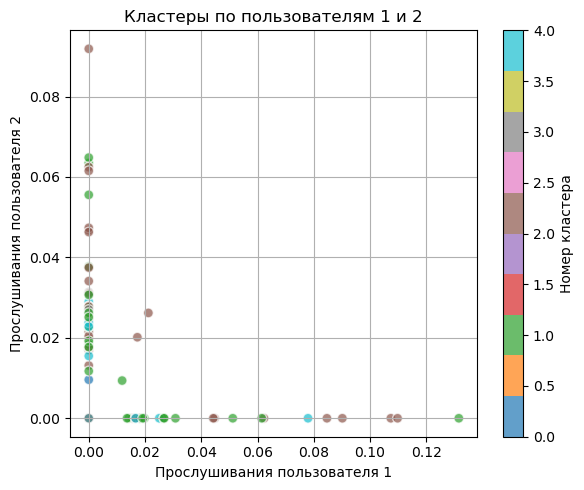

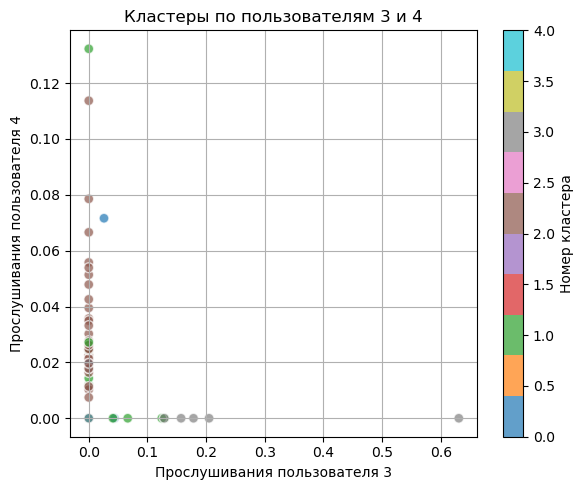

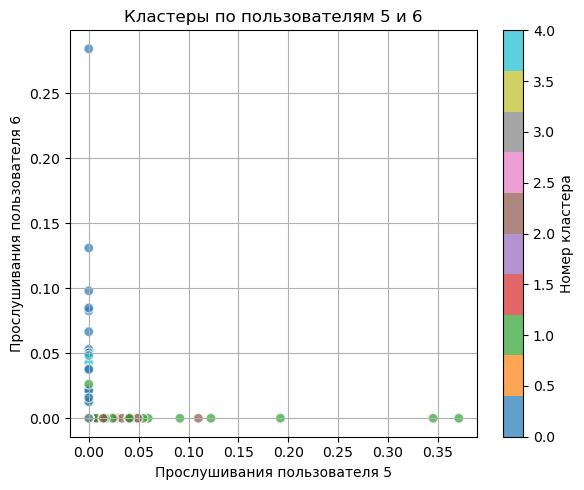

In [69]:
import matplotlib.pyplot as plt

pairs = [
    (1, 2),
    (3, 4),
    (5, 6),
]

for ux, uy in pairs:
    plt.figure(figsize=(6, 5))
    plt.scatter(
        artist_ratings_normalized[ux],
        artist_ratings_normalized[uy],
        c=cluster_labels,
        cmap="tab10",
        alpha=0.7,
        edgecolors="w",
        s=50
    )
    plt.title(f"Кластеры по пользователям {ux} и {uy}")
    plt.xlabel(f"Прослушивания пользователя {ux}")
    plt.ylabel(f"Прослушивания пользователя {uy}")
    plt.colorbar(label="Номер кластера")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


**Ответ:** Отображение только двух колонок не даёт адекватного представления кластеров, так как k-means группирует исполнителей в многомерном пространстве оценок, а проекция на две оси игнорирует информацию остальных измерений, из-за чего точки оказываются сжатыми и перемешанными без видимых границ.

Для визуализации данных высокой размерности существует метод t-SNE (стохастическое вложение соседей с t-распределением). Данный метод является нелинейным методом снижения размерности: каждый объект высокой размерности будет моделироваться объектов более низкой (например, 2) размерности таким образом, чтобы похожие объекты моделировались близкими, непохожие - далекими с большой вероятностью.

Примените `TSNE` из библиотеки `sklearn` и визуализируйте полученные объекты, покрасив их в цвета их кластеров

In [79]:
artist_ratings_normalized

,0,1,2,3,4,5,6,7,8,9,...,4991,4992,4993,4994,4995,4996,4997,4998,4999,cluster
the beatles,0.000000,0.000000,0.000000,0.0,0.012054,0.000000,0.0,0.0,0.025864,0.004880,...,0.0,0.033554,0.010569,0.002199,0.004952,0.0,0.021302,0.0,0.000000,1
radiohead,0.009348,0.084688,0.000000,0.0,0.039505,0.002894,0.0,0.0,0.000000,0.008771,...,0.0,0.000000,0.000000,0.005122,0.000000,0.0,0.000000,0.0,0.000000,2
deathcab for cutie,0.000000,0.017278,0.020144,0.0,0.024333,0.000000,0.0,0.0,0.000000,0.009391,...,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.019622,2
coldplay,0.000000,0.000000,0.000000,0.0,0.011129,0.000000,0.0,0.0,0.000000,0.000000,...,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,3
modest mouse,0.000000,0.000000,0.000000,0.0,0.010260,0.000000,0.0,0.0,0.000000,0.019597,...,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
michal w. smith,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.000000,...,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,3
群星,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.000000,...,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,1
agalloch,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.000000,...,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,4
meshuggah,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.000000,...,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,4


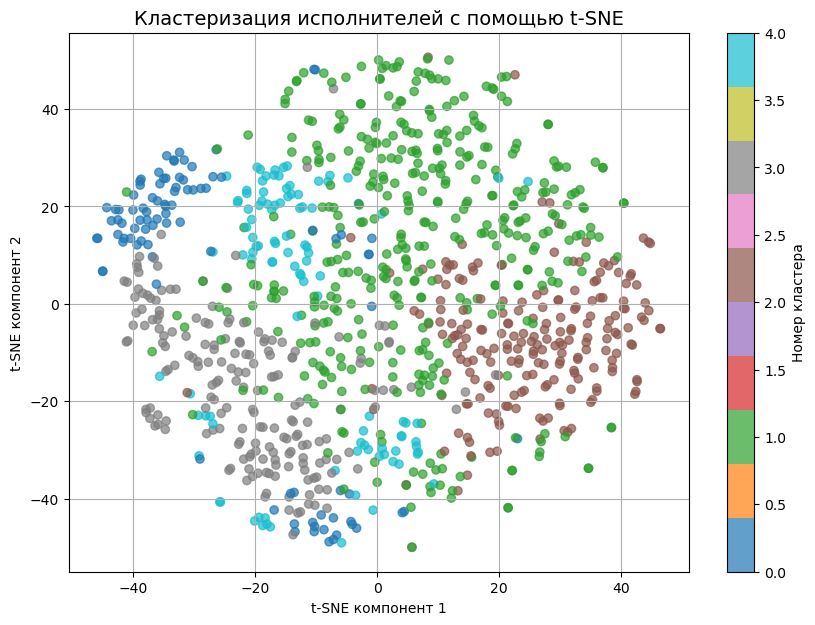

In [81]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, perplexity=30, random_state=42)
features = artist_ratings_normalized.drop(columns=['cluster'])
artist_2d_tsne = tsne.fit_transform(features)

plt.figure(figsize=(10, 7))
scatter = plt.scatter(
    artist_2d_tsne[:, 0],
    artist_2d_tsne[:, 1],
    c=cluster_labels,
    cmap='tab10',
    alpha=0.7
)
plt.title("Кластеризация исполнителей с помощью t-SNE", fontsize=14)
plt.xlabel("t-SNE компонент 1")
plt.ylabel("t-SNE компонент 2")
plt.colorbar(scatter, label="Номер кластера")
plt.grid(True)
plt.show()

## Задание 7 (1 балл) Подбор гиперпараметров

Подберите оптимальное количество кластеров (максимум 100 кластеров) с использованием индекса Силуэта. Зафиксируйте `random_state=42`

Вместо поиска глобального максимума использую "локоть" на производной. Оптимальное k там, где прирост качества замедляется.

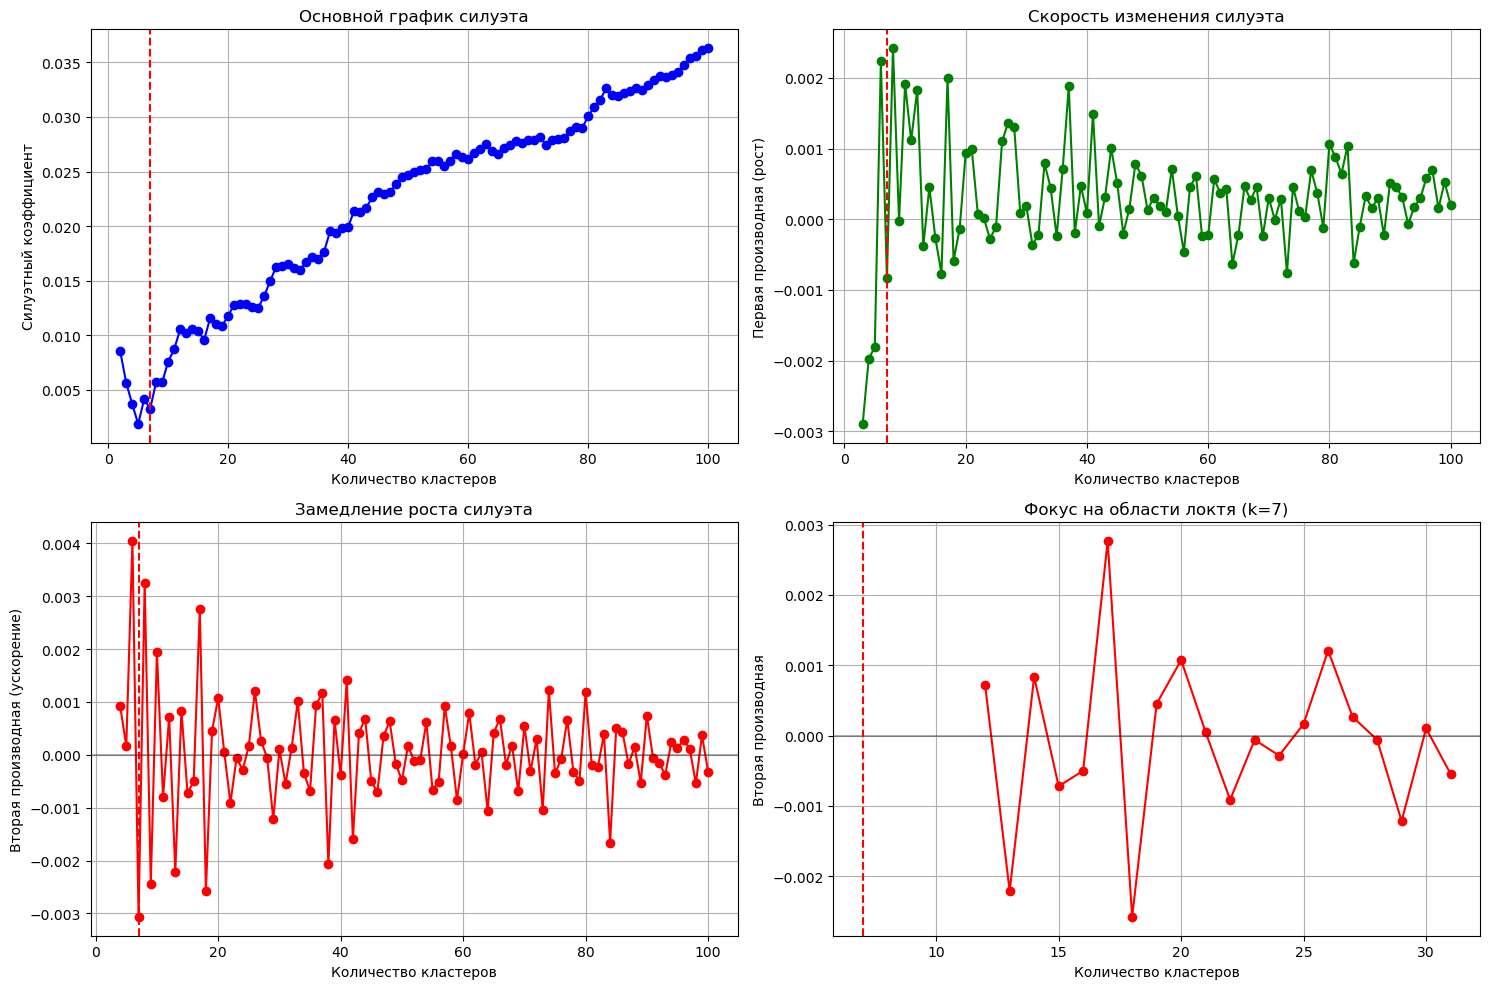

Оптимальное количество кластеров: 7


In [58]:
import matplotlib.pyplot as plt
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import normalize

X_normalized = normalize(artist_ratings, norm='l2')

silhouette_scores = []
K_range = range(2, 101)

for k in K_range:
    model = AgglomerativeClustering(
        n_clusters=k, 
        metric='cosine', 
        linkage='average'
    )
    labels = model.fit_predict(X_normalized)
    score = silhouette_score(X_normalized, labels, metric='cosine')
    silhouette_scores.append(score)


first_derivative = np.diff(silhouette_scores)
second_derivative = np.diff(first_derivative)


elbow_index = np.argmin(second_derivative) + 2
best_k = K_range[elbow_index]

plt.figure(figsize=(15, 10))

plt.subplot(2, 2, 1)
plt.plot(K_range, silhouette_scores, 'bo-')
plt.xlabel('Количество кластеров')
plt.ylabel('Силуэтный коэффициент')
plt.title('Основной график силуэта')
plt.grid(True)
plt.axvline(x=best_k, color='r', linestyle='--')

plt.subplot(2, 2, 2)
plt.plot(K_range[1:], first_derivative, 'go-')
plt.xlabel('Количество кластеров')
plt.ylabel('Первая производная (рост)')
plt.title('Скорость изменения силуэта')
plt.grid(True)
plt.axvline(x=best_k, color='r', linestyle='--')

plt.subplot(2, 2, 3)
plt.plot(K_range[2:], second_derivative, 'ro-')
plt.xlabel('Количество кластеров')
plt.ylabel('Вторая производная (ускорение)')
plt.title('Замедление роста силуэта')
plt.grid(True)
plt.axhline(y=0, color='k', linestyle='-', alpha=0.3)
plt.axvline(x=best_k, color='r', linestyle='--')

plt.subplot(2, 2, 4)
plt.plot(K_range[10:30], second_derivative[8:28], 'ro-')
plt.xlabel('Количество кластеров')
plt.ylabel('Вторая производная')
plt.title(f'Фокус на области локтя (k={best_k})')
plt.grid(True)
plt.axhline(y=0, color='k', linestyle='-', alpha=0.3)
plt.axvline(x=best_k, color='r', linestyle='--')

plt.tight_layout()
plt.show()

print(f"Оптимальное количество кластеров: {best_k}")

Выведите исполнителей, ближайших с центроидам (аналогично заданию 5). Как соотносятся результаты? Остался ли смысл кластеров прежним? Расскажите про смысл 1-2 интересных кластеров, если он изменился и кластеров слишком много, чтобы рассказать про все.

In [99]:
from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import cosine_similarity

kmeans = KMeans(n_clusters=7, random_state=1504, n_init='auto')
old_labels = kmeans.fit_predict(features)

counts = np.bincount(old_labels)  

order = np.argsort(-counts)

mapping = { old: new for new, old in enumerate(order) }

sorted_labels = np.array([mapping[old] for old in old_labels])

sorted_centers = kmeans.cluster_centers_[order]

cos_sim = cosine_similarity(sorted_centers, features)

top_n = 10
for new_idx in range(sorted_centers.shape[0]):
    top_idx = np.argsort(cos_sim[new_idx])[::-1][:top_n]
    print(f"\n=== Кластер {new_idx} (size={counts[order[new_idx]]}) ===")
    for i in top_idx:
        print(artist_ratings_normalized.index[i])


C:\Users\K\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(



=== Кластер 0 (size=327) ===
the beatles
the rolling stones
led zeppelin.
dylan. bob
radiohead
r.e.m.
white stripes
who
coldplay
u2

=== Кластер 1 (size=184) ===
fall out boy
paramore
the all-americian rejects
dashboard confesssional
cartel
kelly clarkson
anberlin
taking back sunday
maroon5
the fray

=== Кластер 2 (size=139) ===
sufjan stevens
the arcade fire
broken social scene
radiohead
belle and sebastian
the shins
animal collective
beirut
of montreal
deathcab for cutie

=== Кластер 3 (size=116) ===
sonic youth
fugazi
jawbreaker
the pixies
velvet underground
descendents
pavement
against me!
my bloody valentine
liars

=== Кластер 4 (size=89) ===
massive attack
portishead
lamb
thievery corporation
amon tobin
dj shadow
tricky & dj muggs & grease
boards of canada
groove armada
morcheeba

=== Кластер 5 (size=83) ===
metallica
iron maiden
koЯn
mudvayne
system of a down
megadeth
slayer
in flames
disturbed
cob

=== Кластер 6 (size=62) ===
nas
jay-z
a tribe called quest
the roots featuring 

**Ответ:** После перенумерации по размеру «новые» кластеры лишь формально получили другие номера, но их «смысл» (жанровая направленность) в целом сохранился.
**Кластер 0** 

В прежней нумерации этот набор исполнителей разбивался на несколько кластеров (гранж/альтернативный рок и трэш/ню-метал). Теперь же, благодаря огромному числу слушателей, все эти «тёмные» и «экспериментальные» течения объединились в единый, самый массовый кластер.

**Кластер 5**

Практически совпадает с прежним Кластером 0 («Интеллектуальный хип-хоп 90-х»): те же исполнители, почти в том же порядке по схожести..терах.

Сделайте t-SNE визуализацию полученной кластеризации.

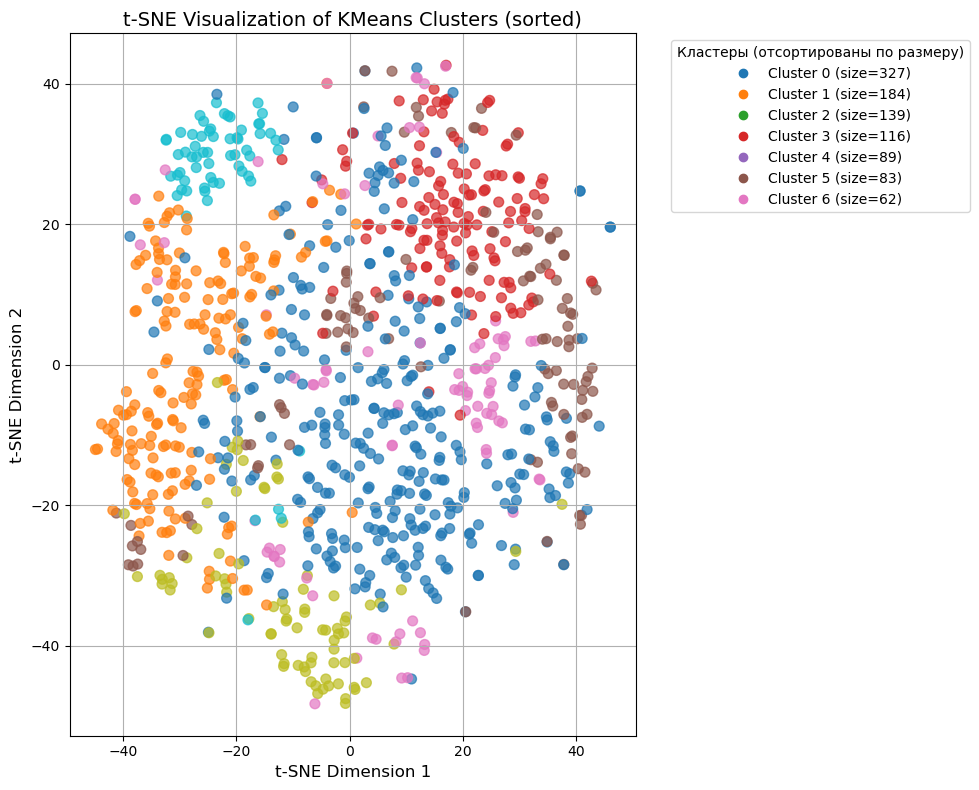

In [101]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import matplotlib

tsne = TSNE(n_components=2, random_state=1504)
X_tsne = tsne.fit_transform(features)

cmap = matplotlib.colormaps['tab10']

plt.figure(figsize=(10, 8))
scatter = plt.scatter(
    X_tsne[:, 0],
    X_tsne[:, 1],
    c=sorted_labels,
    cmap=cmap,
    s=50,
    alpha=0.7
)

handles = [
    plt.Line2D([], [], marker="o", linestyle="",
               color=cmap(i), label=f'Cluster {i} (size={counts[order[i]]})')
    for i in np.unique(sorted_labels)
]

plt.legend(handles=handles, title="Кластеры (отсортированы по размеру)",
           bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title('t-SNE Visualization of KMeans Clusters (sorted)', fontsize=14)
plt.xlabel('t-SNE Dimension 1', fontsize=12)
plt.ylabel('t-SNE Dimension 2', fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.show()

Если кластеров получилось слишком много и визуально цвета плохо отличаются, покрасьте только какой-нибудь интересный кластер из задания выше (`c = (labels == i)`). Хорошо ли этот кластер отражается в визуализации?

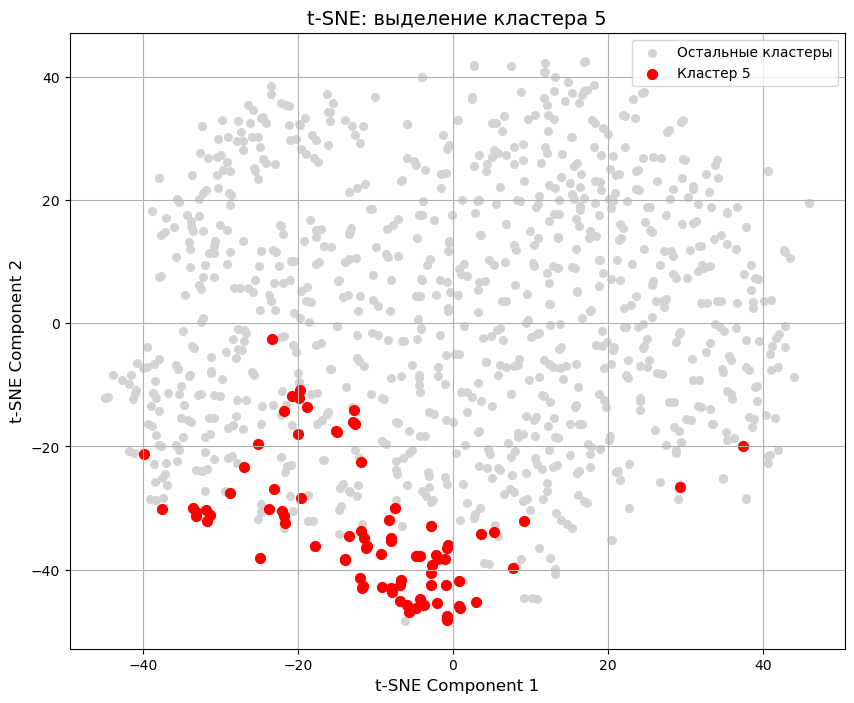

In [103]:
cluster_i = 5
mask = (sorted_labels == cluster_i)

plt.figure(figsize=(10, 8))
plt.scatter(
    X_tsne[~mask, 0], X_tsne[~mask, 1],
    c='lightgray', s=30, label='Остальные кластеры'
)
plt.scatter(
    X_tsne[mask, 0], X_tsne[mask, 1],
    c='red', s=50, label=f'Кластер {cluster_i}'
)
plt.title(f't-SNE: выделение кластера {cluster_i}', fontsize=14)
plt.xlabel('t-SNE Component 1', fontsize=12)
plt.ylabel('t-SNE Component 2', fontsize=12)
plt.legend()
plt.grid(True)
plt.show()

**Ответ:** Класс выделяется умеренно хорошо, оон расположен в левом нижнем углу